In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
from src.data.load_data import load_data

from src.eda.overview import (
    dataset_info,
    summary_statistics,
    missing_values,
    duplicated_rows,
)

from src.eda.distributions import (
    resale_price_distribution,
    depreciation_distribution,
)

from src.eda.correlations import (
    resale_price_correlations,
    add_depreciation_column,
)

from src.eda.time_analysis import (
    describe_time_columns,
    plot_time_histograms,
    time_correlations,
)

from src.eda.numerical_analysis import (
    original_vs_resale,
    age_vs_resale,
    age_vs_depreciation,
    battery_health_analysis,
    hardware_correlations,
)

from src.eda.condition_analysis import (
    condition_price,
    condition_summary,
    condition_crosstabs,
)

from src.eda.binary_analysis import (
    binary_feature_summary,
)

from src.eda.categorical_analysis import (
    brand_prices,
    model_prices,
    seller_prices,
    city_prices,
    os_prices,
    brand_os_table,
    brand_os_summary,
    list_models,
    apple_models,
)

In [3]:
df = load_data()

print(df.head())

     brand       model  release_year  ram_gb  storage_gb  screen_size_inches  \
0   Realme   Realme GT          2025       4         256                6.93   
1  Samsung  Galaxy S21          2024      16          64                6.29   
2    Apple   iPhone 11          2022       4         128                5.52   
3   Google     Pixel 6          2024      16         512                5.99   
4   Google     Pixel 7          2021       4         128                6.59   

   battery_capacity  processor_score  camera_score  os_type  ...  body_damage  \
0              4130               47           100  Android  ...            0   
1              5558               81            67  Android  ...            0   
2              5945               59            67      iOS  ...            0   
3              5767               84            57  Android  ...            0   
4              5336               98            44  Android  ...            0   

   repair_history  water_damage 

In [4]:
dataset_info(df)

print("\nSummary Statistics")
display(summary_statistics(df))

print("\nMissing Values")
display(missing_values(df))

print(f"\nDuplicated Rows: {duplicated_rows(df)}")

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 28 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   brand                      1000000 non-null  str    
 1   model                      1000000 non-null  str    
 2   release_year               1000000 non-null  int64  
 3   ram_gb                     1000000 non-null  int64  
 4   storage_gb                 1000000 non-null  int64  
 5   screen_size_inches         1000000 non-null  float64
 6   battery_capacity           1000000 non-null  int64  
 7   processor_score            1000000 non-null  int64  
 8   camera_score               1000000 non-null  int64  
 9   os_type                    1000000 non-null  str    
 10  has_5g                     1000000 non-null  int64  
 11  original_price             1000000 non-null  int64  
 12  purchase_year              1000000 non-null  int64  
 13  age_months              

,release_year,ram_gb,storage_gb,screen_size_inches,battery_capacity,processor_score,camera_score,has_5g,original_price,purchase_year,...,battery_health,screen_cracked,body_damage,repair_history,water_damage,warranty_remaining_months,box_available,charger_available,market_demand_score,resale_price
count,1000000.000000,1000000.000000,1000000.000000,1000000.00000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,...,1000000.000000,1000000.000000,1000000.000000,1000000.00000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,2022.001836,9.201878,396.798912,6.25037,4750.004425,70.018905,69.980058,0.800063,79966.195735,2023.501257,...,77.507898,0.079978,0.119653,0.15053,0.030106,8.099701,0.699651,0.849771,70.020885,22597.996211
std,2.001558,4.309755,349.401760,0.43290,1009.971322,17.600272,17.607651,0.399953,40413.479880,1.607323,...,13.272198,0.271259,0.324555,0.35759,0.170879,8.158009,0.458410,0.357296,17.618549,16652.621181
min,2019.000000,4.000000,64.000000,5.50000,3000.000000,40.000000,40.000000,0.000000,10000.000000,2019.000000,...,55.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,40.000000,2000.000000
25%,2020.000000,6.000000,128.000000,5.88000,3877.000000,55.000000,55.000000,1.000000,45028.000000,2023.000000,...,66.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000,55.000000,10365.927500
50%,2022.000000,8.000000,256.000000,6.25000,4750.000000,70.000000,70.000000,1.000000,79947.000000,2024.000000,...,78.000000,0.000000,0.000000,0.00000,0.000000,6.000000,1.000000,1.000000,70.000000,18555.195000
75%,2024.000000,12.000000,512.000000,6.63000,5623.000000,85.000000,85.000000,1.000000,114984.000000,2025.000000,...,89.000000,0.000000,0.000000,0.00000,0.000000,15.000000,1.000000,1.000000,85.000000,30427.912500
max,2025.000000,16.000000,1024.000000,7.00000,6500.000000,100.000000,100.000000,1.000000,150000.000000,2025.000000,...,100.000000,1.000000,1.000000,1.00000,1.000000,24.000000,1.000000,1.000000,100.000000,160257.480000



Missing Values


brand                        0
model                        0
release_year                 0
ram_gb                       0
storage_gb                   0
screen_size_inches           0
battery_capacity             0
processor_score              0
camera_score                 0
os_type                      0
has_5g                       0
original_price               0
purchase_year                0
age_months                   0
usage_hours_per_day          0
condition                    0
battery_health               0
screen_cracked               0
body_damage                  0
repair_history               0
water_damage                 0
city_tier                    0
seller_type                  0
warranty_remaining_months    0
box_available                0
charger_available            0
market_demand_score          0
resale_price                 0
dtype: int64


Duplicated Rows: 0


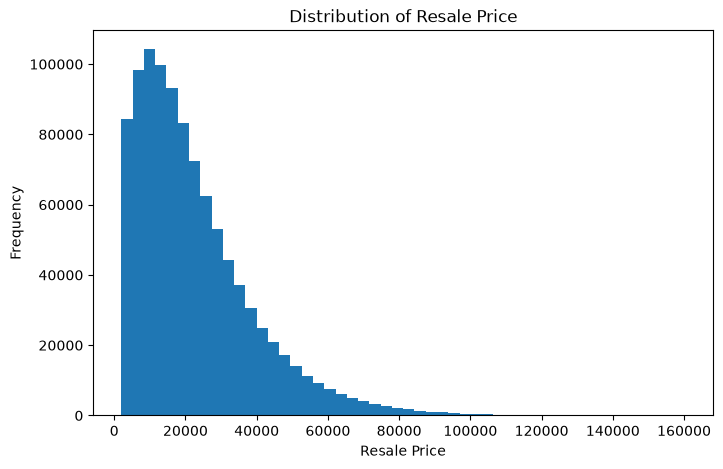

In [5]:
resale_price_distribution(df)

In [6]:
display(resale_price_correlations(df))

resale_price                 1.000000
original_price               0.657741
market_demand_score          0.327644
battery_health               0.223399
warranty_remaining_months    0.046543
charger_available            0.013778
box_available                0.011996
screen_size_inches           0.002079
storage_gb                   0.001079
processor_score              0.001059
ram_gb                       0.000383
purchase_year                0.000326
camera_score                -0.000117
usage_hours_per_day         -0.000378
battery_capacity            -0.000384
release_year                -0.000390
has_5g                      -0.000837
repair_history              -0.038426
body_damage                 -0.064714
water_damage                -0.090100
screen_cracked              -0.090594
age_months                  -0.396635
Name: resale_price, dtype: float64

count    1000000.000000
mean          71.061176
std           14.727796
min          -50.648687
25%           63.228194
50%           73.941495
75%           81.870863
max           98.595900
Name: depreciation_pct, dtype: float64

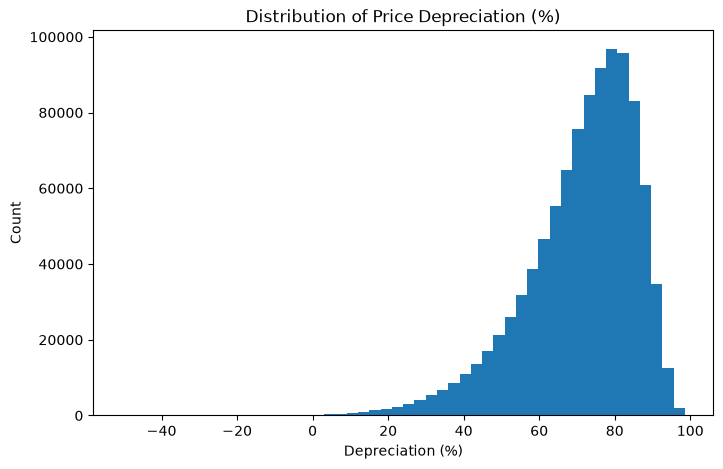

In [7]:
df = add_depreciation_column(df)

display(df["depreciation_pct"].describe())

depreciation_distribution(df)

,count,mean,std,min,25%,50%,75%,max
release_year,1000000.0,2022.001836,2.001558,2019.0,2020.0,2022.0,2024.0,2025.0
purchase_year,1000000.0,2023.501257,1.607323,2019.0,2023.0,2024.0,2025.0,2025.0
age_months,1000000.0,35.986390,20.504100,1.0,18.0,36.0,54.0,71.0
warranty_remaining_months,1000000.0,8.099701,8.158009,0.0,0.0,6.0,15.0,24.0


resale_price                 1.000000
warranty_remaining_months    0.046543
purchase_year                0.000326
release_year                -0.000390
age_months                  -0.396635
Name: resale_price, dtype: float64

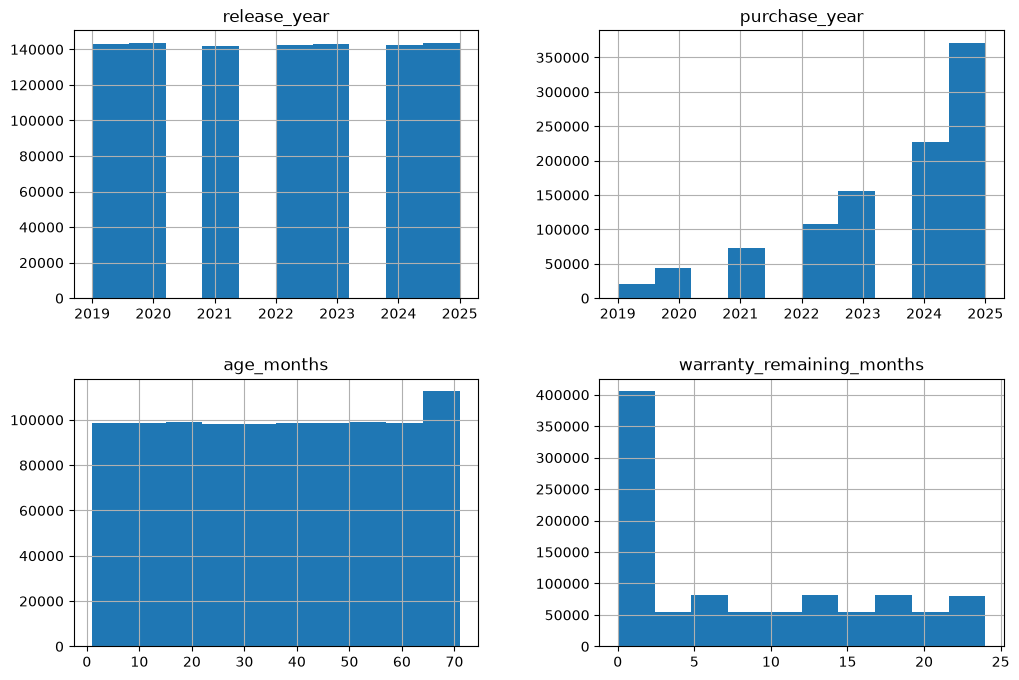

In [8]:
display(describe_time_columns(df))

plot_time_histograms(df)

display(time_correlations(df))

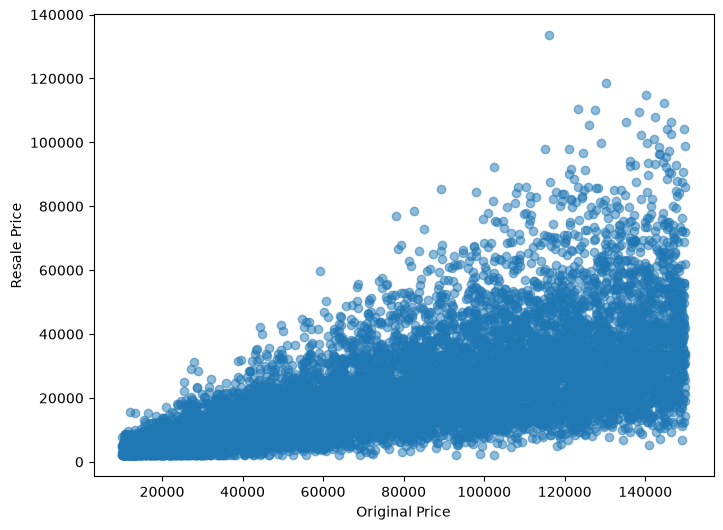

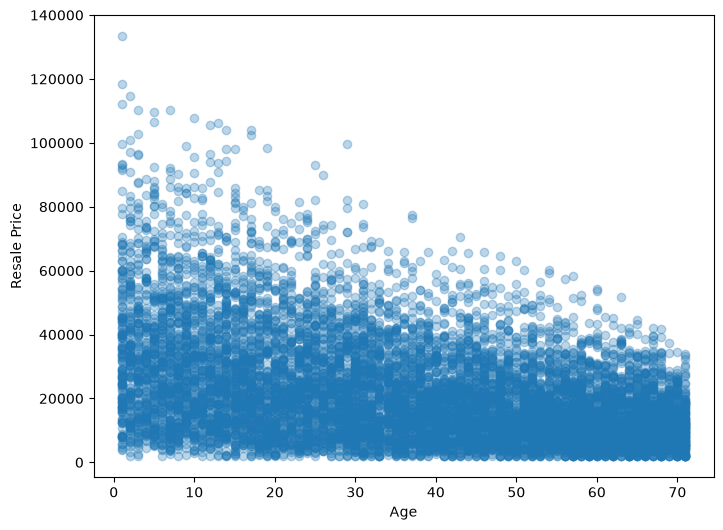

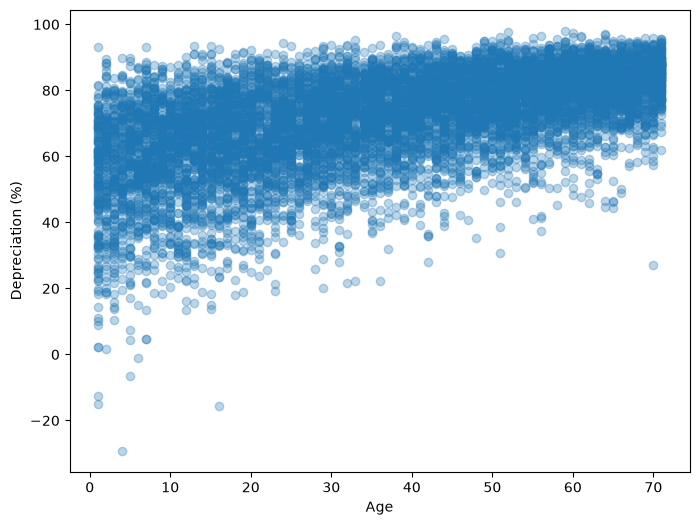

In [9]:
original_vs_resale(df)

age_vs_resale(df)

age_vs_depreciation(df)

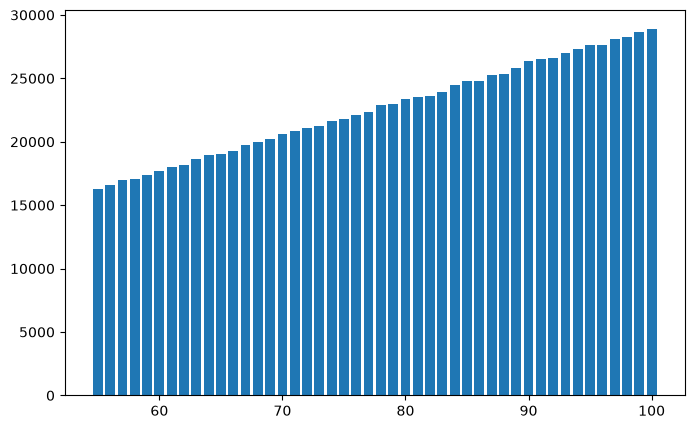

battery_health
100    28914.988125
99     28654.145365
98     28283.547823
97     28124.067580
96     27658.276608
95     27601.160445
94     27346.290149
93     26972.572440
92     26623.189461
91     26506.210442
90     26357.592536
89     25790.287494
88     25347.969344
87     25239.555334
85     24821.935161
86     24811.963220
84     24490.012877
83     23892.946471
82     23584.589539
81     23557.229398
80     23388.201992
79     22942.151950
78     22863.614194
77     22355.116175
76     22150.538990
75     21829.979036
74     21624.762400
73     21256.386279
72     21050.916203
71     20843.621025
70     20588.048255
69     20229.778582
68     19968.330307
67     19736.084397
66     19309.503529
65     19031.473942
64     18942.599294
63     18627.378172
62     18177.421177
61     17985.771060
60     17711.734819
59     17350.267525
58     17091.326164
57     16949.781401
56     16565.755624
55     16256.990175
Name: resale_price, dtype: float64

In [10]:
display(battery_health_analysis(df))

In [11]:
display(hardware_correlations(df))

,ram_gb,storage_gb,processor_score,camera_score,battery_capacity
ram_gb,1.000000,0.000090,-0.001079,-0.000019,0.000130
storage_gb,0.000090,1.000000,-0.001639,-0.003498,0.000720
processor_score,-0.001079,-0.001639,1.000000,-0.000275,0.000613
camera_score,-0.000019,-0.003498,-0.000275,1.000000,0.000242
battery_capacity,0.000130,0.000720,0.000613,0.000242,1.000000


In [12]:
display(condition_price(df))

display(condition_summary(df))

condition_crosstabs(df)

condition
Excellent    26716.697269
Good         24141.209387
Fair         20297.386199
Poor         15128.744768
Name: resale_price, dtype: float64

,Avg_Battery,Avg_Age,Cracked_Rate,Damage_Rate,Water_Damage_Rate,Repair_Rate
condition,,,,,,
Excellent,77.502034,35.993243,0.080187,0.120243,0.029652,0.151919
Fair,77.520528,35.997752,0.079542,0.120388,0.029947,0.151042
Good,77.497021,35.968404,0.079789,0.118605,0.030291,0.149448
Poor,77.525188,36.010507,0.081619,0.120461,0.030745,0.150549



=== screen_cracked ===
screen_cracked         0         1
condition                         
Excellent       0.919813  0.080187
Fair            0.920458  0.079542
Good            0.920211  0.079789
Poor            0.918381  0.081619

=== body_damage ===
body_damage         0         1
condition                      
Excellent    0.879757  0.120243
Fair         0.879612  0.120388
Good         0.881395  0.118605
Poor         0.879539  0.120461

=== water_damage ===
water_damage         0         1
condition                       
Excellent     0.970348  0.029652
Fair          0.970053  0.029947
Good          0.969709  0.030291
Poor          0.969255  0.030745

=== repair_history ===
repair_history         0         1
condition                         
Excellent       0.848081  0.151919
Fair            0.848958  0.151042
Good            0.850552  0.149448
Poor            0.849451  0.150549


In [13]:
display(binary_feature_summary(df))

,Feature,Mean (0),Mean (1),% Change
0,has_5g,22625.890119,22591.025480,-0.154092
1,screen_cracked,23042.800760,17481.214470,-24.135895
2,body_damage,22995.295844,19674.863987,-14.439614
3,repair_history,22867.364374,21077.899401,-7.825410
4,water_damage,22862.340694,14081.882220,-38.405772
5,box_available,22293.092332,22728.886577,1.954840
6,charger_available,22052.314490,22694.465989,2.911946


In [14]:
display(brand_prices(df))

brand
Apple      26799.983454
Samsung    24298.011150
Google     23635.793967
OnePlus    22458.514789
Xiaomi     20835.686344
Vivo       20269.138463
Realme     19896.026356
Name: resale_price, dtype: float64

In [15]:
display(model_prices(df))

model
iPhone 15          26889.994641
iPhone 13          26875.892723
iPhone 14          26783.620264
iPhone 11          26758.753951
iPhone 12          26691.903081
Galaxy S21         24420.835731
Galaxy S23         24322.777145
Galaxy S22         24307.077686
Galaxy A54         24138.993766
Pixel 7            23750.041399
Pixel 6            23619.595661
Pixel 8            23536.958515
Nord 3             22624.141829
OnePlus 9          22439.605301
OnePlus 10         22389.768950
OnePlus 11         22381.162175
Poco X5            20902.924404
Redmi Note 12      20802.254805
Mi 11              20802.071929
Vivo V27           20272.141191
Vivo X90           20266.136534
Realme Narzo 60    19973.903345
Realme GT          19817.761821
Name: resale_price, dtype: float64

In [16]:
display(seller_prices(df))

seller_type
Store         22601.940505
Individual    22594.056066
Name: resale_price, dtype: float64

In [17]:
display(city_prices(df))

city_tier
Tier2    22632.413161
Tier3    22597.508978
Tier1    22564.043846
Name: resale_price, dtype: float64

In [18]:
display(os_prices(df))

os_type
iOS        26799.983454
Android    21898.620770
Name: resale_price, dtype: float64

In [19]:
display(brand_os_table(df))

display(brand_os_summary(df))

os_type,Android,iOS
brand,,
Apple,0,142690
Google,142795,0
OnePlus,143120,0
Realme,142626,0
Samsung,142735,0
Vivo,142991,0
Xiaomi,143043,0


,,Models,Phones
brand,os_type,,
Apple,iOS,5,142690
Google,Android,3,142795
OnePlus,Android,4,143120
Realme,Android,2,142626
Samsung,Android,4,142735
Vivo,Android,2,142991
Xiaomi,Android,3,143043


In [20]:
list_models(df)


Apple
['iPhone 11', 'iPhone 12', 'iPhone 13', 'iPhone 14', 'iPhone 15']

Google
['Pixel 6', 'Pixel 7', 'Pixel 8']

OnePlus
['Nord 3', 'OnePlus 10', 'OnePlus 11', 'OnePlus 9']

Realme
['Realme GT', 'Realme Narzo 60']

Samsung
['Galaxy A54', 'Galaxy S21', 'Galaxy S22', 'Galaxy S23']

Vivo
['Vivo V27', 'Vivo X90']

Xiaomi
['Mi 11', 'Poco X5', 'Redmi Note 12']


In [21]:
display(apple_models(df))

model
iPhone 15    26889.994641
iPhone 13    26875.892723
iPhone 14    26783.620264
iPhone 11    26758.753951
iPhone 12    26691.903081
Name: resale_price, dtype: float64